# Домашнее задание: Создание Multi-Task классификатора токсичности (Энкодеры)

Добро пожаловать на продвинутое домашнее задание по трансформерным энкодерам!

В этом задании вам предстоит пройти весь путь создания production-ready NLP модели: от формализации бизнес-задачи и сбора данных до обучения Multi-Task энкодера с ранней остановкой и деплоя готового решения на Hugging Face.

Вам предстоит создать модель, которая будет одновременно предсказывать три независимых класса токсичности для одного текста:
1. Ненормативная лексика (Profanity)
2. Угрозы (Threats)
3. Запросы на нарушение закона (Illegal acts, например, "как создать бомбу")

---

## Часть 1: Формализация задачи (10 баллов)

Представьте, что вы работаете в социальной сети или платформе для общения. Бизнес пришел к вам с запросом: "Нам нужно автоматически фильтровать и помечать токсичные комментарии пользователей по трем категориям, чтобы модераторы могли быстрее реагировать на угрозы, а алгоритмы могли автоматически скрывать мат".

**Задание 1.1: Бизнес-метрики (3 балла)**
Предложите 2-3 бизнес-метрики, которые будет оптимизировать ваше решение. Оцифруйте их (например, "снижение времени реакции модератора на...").




Снижение времени реакции модераторов на критичный контент на 70%

    Сейчас: модератор вручную просматривает поток из ~500 сообщений/час, на поиск одной реальной угрозы уходит в среднем 12 минут
    С моделью: система автоматически выделяет ~15 подозрительных сообщений из тех же 500, модератор проверяет только их за 3–4 минуты
    Цель: сократить время от публикации угрозы до реакции модератора с 12 до 3–4 минут

Снижение нагрузки на команду модерации на 60%

    Сейчас: для обработки 10,000 комментариев/день нужна команда из 5 модераторов (каждый вручную проверяет ~2000 сообщений)
    С моделью: автоматическое скрытие очевидного мата (при уверенности модели >80%) без участия человека снижает объём ручной проверки до ~4000 сообщений/день
    Цель: обрабатывать тот же объём силами 2–3 модераторов вместо 5

Рост пользовательской удовлетворённости платформой (NPS) на 15–20%

    Быстрое удаление токсичных комментариев снижает количество жалоб пользователей на "безнаказанность хамов" и улучшает восприятие платформы как "безопасного места"
    Метрика: доля пользователей, оценивающих модерацию как "хорошую/отличную" в ежемесячных опросах



**Задание 1.2: Сведение к ML-задаче (3 балла)**
Сведите бизнес-задачу к ML-задаче. Опишите:
- Тип задачи (какая это классификация?)
- Объект (что подается на вход?)
- Метки (в каком формате модель выдает ответ?)


Тип задачи:
Multi-label бинарная классификация текста (multi-task learning).

    Не multi-class (где классы взаимоисключающие: либо A, либо B, либо C), а именно multi-label: один текст может одновременно относиться к нескольким категориям. Например, фраза "Убью тебя, мудак!" — это и мат (profanity = 1), и угроза (threat = 1) одновременно.
    У нас три независимых бинарных вопроса для каждого текста: "есть ли мат?", "есть ли угроза?", "есть ли незаконный запрос?".

Объект (что на входе):
Строка текста — комментарий пользователя на русском языке (от 1 слова до ~500 символов).

Метки (что на выходе):
Модель выдаёт три независимых вероятности (числа от 0 до 1):

    profanity — вероятность присутствия ненормативной лексики
    threat — вероятность того, что текст содержит угрозу
    illegal — вероятность запроса на незаконные действия

После применения порогов (разных для каждого класса!) получаем вектор из трёх бинарных меток: [0/1, 0/1, 0/1].
Пример: [1, 0, 0] = "мат есть, угроз нет, незаконных запросов нет".

**Задание 1.3: ML-метрики (4 балла)**
Предложите оффлайн метрики для оценки качества модели. Учтите, что классы могут быть сильно несбалансированы (мат встречается часто, а запросы на нарушение закона — редко).


Основные метрики (оффлайн, на валидационной выборке):

    F1-score для каждого класса отдельно (главная метрика)
        Почему не accuracy? При сильном дисбалансе (мат встречается в 30% комментариев, а незаконные запросы — в 0.5%) наивная модель, всегда предсказывающая "0" для illegal, получит accuracy = 99.5%, но при этом не будет ловить ни одного опасного запроса.
        F1-score учитывает баланс между Precision (насколько точны наши тревоги) и Recall (сколько реальных случаев мы поймали), что критично для несбалансированных классов.
        Целевые значения: profanity F1 ≥ 0.75, threat F1 ≥ 0.60, illegal F1 ≥ 0.50 (для редких классов планка ниже).

    Recall для класса threat (приоритет — не пропустить реальную угрозу)
        Для угроз цена False Negative (пропустили реальную угрозу) гораздо выше, чем цена False Positive (модератор лишний раз проверит безобидный комментарий).
        Целевое значение: threat recall ≥ 0.70 — ловим хотя бы 7 из 10 реальных угроз.

    Precision для класса profanity (чтобы не перегрузить модераторов ложными тревогами)
        Мат — самый частый класс, и если модель будет слишком "параноидной", модераторы утонут в ложных срабатываниях.
        Целевое значение: profanity precision ≥ 0.80 — из 10 сообщений, помеченных как мат, хотя бы 8 действительно содержат мат.

    Macro-averaged F1 (агрегированная метрика по всем трём классам)
        Среднее арифметическое F1 по трём классам — показывает общее качество модели без перекоса в сторону частых классов.
        Целевое значение: macro F1 ≥ 0.60.

Дополнительные метрики (для глубокой диагностики):

    Confusion matrix для каждого класса — покажет, в какую сторону "ошибается" модель (слишком осторожная или слишком агрессивная).

    Распределение предсказанных вероятностей — если модель почти всегда выдаёт вероятности близко к 0.5 (не уверена) — это сигнал, что ей не хватает обучающих данных.

Почему именно такой набор:

    F1 вместо accuracy — защита от дисбаланса классов
    Раздельные метрики для каждого класса — у них разные требования (threat нельзя пропускать, profanity нельзя переоценивать)
    Приоритет Recall для угроз — безопасность важнее удобства модераторов
    Приоритет Precision для мата — иначе модераторы перестанут доверять системе из-за шума


---

## Часть 2: Сбор, очистка и аналитика датасета (15 баллов)

Вам необходимо собрать датасет для обучения. Вы можете использовать готовые открытые датасеты (например, `Kaggle Toxic Comment Classification Challenge`, переведенный на русский, или русскоязычные датасеты вроде `ru_toxic_comments`).

**Задание 2.1: Сбор и очистка (7 баллов)**
Загрузите данные (минимум 5000 примеров). Очистите текст от ссылок, HTML-тегов и лишних символов. Приведите метки к формату трех бинарных колонок: `profanity`, `threat`, `illegal`.


In [1]:
import re
import random
import itertools
import pandas as pd
import numpy as np

random.seed(42)
np.random.seed(42)

# -----------------------------------------------------------------
# 1. Попытка загрузить реальный открытый датасет (best-effort)
# -----------------------------------------------------------------
def try_load_real_dataset(limit=4000):
    """
    Пытаемся подтянуть реальные тексты токсичных/нейтральных
    русскоязычных комментариев. Если по каким-то причинам не
    получилось (нет сети, датасет переехал/переименован) —
    просто продолжаем работу на синтетике ниже, без падения кода.
    """
    texts, is_toxic = [], []
    try:
        from datasets import load_dataset
        ds = load_dataset("s-nlp/ru_paradetox")
        split = ds["train"]
        cols = split.column_names
        tox_col = next((c for c in cols if "tox" in c.lower()), None)
        neu_col = next((c for c in cols if "neu" in c.lower()), None)
        if tox_col and neu_col:
            n = min(limit, len(split))
            for row in split.select(range(n)):
                t, nn = row.get(tox_col), row.get(neu_col)
                if t:
                    texts.append(t); is_toxic.append(1)
                if nn:
                    texts.append(nn); is_toxic.append(0)
        print(f"[OK] Загружено {len(texts)} реальных примеров из s-nlp/ru_paradetox")
    except Exception as e:
        print(f"[WARN] Не удалось загрузить реальный датасет ({e}).")
        print("       Продолжаем работу на синтетическом корпусе ниже.")
    return texts, is_toxic

real_texts, real_toxic_flags = try_load_real_dataset()

# -----------------------------------------------------------------
# 2. Очистка текста: ссылки, HTML-теги, лишние символы
# -----------------------------------------------------------------
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)          # ссылки
    text = re.sub(r'<.*?>', ' ', text)                      # html-теги
    text = re.sub(r'@\w+', ' ', text)                        # упоминания
    text = re.sub(r'[^а-яёa-z0-9\s\.\,\!\?\-]', ' ', text)   # лишние символы
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)               # круууто -> круто
    text = re.sub(r'\s+', ' ', text).strip()
    return text


README.md:   0%|          | 0.00/5.58k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/2.32M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/235k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11090 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1116 [00:00<?, ? examples/s]

[OK] Загружено 8000 реальных примеров из s-nlp/ru_paradetox


In [2]:
PROFANITY_PATTERNS = [
    r"\bху[йяеёи]\w*", r"\bпизд\w*", r"\bеб[а-я]{1,4}\b", r"\bбля[а-я]*",
    r"\bмуда\w*", r"\bгандон\w*", r"\bсук[аи]\w*", r"\bтварь\w*",
    r"\bсволоч\w*", r"\bидиот\w*", r"\bдебил\w*", r"\bурод\w*", r"\bпридурок\w*",
]

THREAT_PATTERNS = [
    r"убь[юё]\w*", r"прибь[юё]\w*", r"уничтож\w*", r"пожале[её]шь\w*",
    r"найд[уё]\s+тебя", r"конец\s+тебе", r"смерть\s+тебе",
    r"поплатишься", r"будет\s+больно", r"зарежу\w*",
    r"сожгу\w*", r"закопаю\w*", r"голову\s+оторву",
]

ILLEGAL_PATTERNS = [
    r"как\s+сделать\s+бомбу", r"как\s+изготовить\s+взрывчатку",
    r"где\s+купить\s+наркотик\w*", r"как\s+достать\s+оружие",
    r"как\s+взломать\s+\w+", r"рецепт\s+изготовления\s+наркотик\w*",
    r"как\s+угнать\s+машину", r"поддельн\w*\s+документ\w*",
    r"как\s+обойти\s+закон", r"инструкция\s+по\s+взлому",
]

def match_any(text, patterns):
    return int(any(re.search(p, text) for p in patterns))

In [3]:
# --- neutral (класс 0,0,0) ---
neutral_subjects = ["Сегодня", "Вчера", "Вчера вечером", "На выходных", "Утром",
                     "После работы", "На прошлой неделе", "Только что", "Недавно",
                     "В прошлом месяце", "Каждое утро", "По дороге домой",
                     "В обеденный перерыв", "На каникулах"]
neutral_actions = ["сходил в кино", "приготовил ужин", "закончил отчет", "гулял в парке",
                    "купил новый телефон", "посмотрел сериал", "убрался в квартире",
                    "сыграл в футбол", "почитал книгу", "запустил новый проект",
                    "сходил на тренировку", "заказал пиццу", "посадил цветы",
                    "починил велосипед", "встретился с друзьями", "написал письмо клиенту",
                    "провел встречу с командой", "съездил на дачу", "побывал на выставке",
                    "сходил в магазин за продуктами", "посетил стоматолога",
                    "прогулялся с собакой", "приготовил завтрак", "забронировал отель",
                    "обновил резюме"]
neutral_adverbs = ["с удовольствием", "как обычно", "неожиданно для себя",
                    "в хорошем настроении", "совершенно случайно", "наконец-то",
                    "в этот раз", "без особых проблем", "довольно быстро",
                    "с друзьями", "в одиночестве", "как всегда"]

def generate_neutral(n):
    combos = [f"{s}, я {a} {act}." for s, a, act in
              itertools.product(neutral_subjects, neutral_adverbs, neutral_actions)]
    random.shuffle(combos)
    return combos[:n]

# --- profanity (класс 1,0,0) ---
profanity_words = ["бля", "хуй", "пизда", "ебаный", "мудак", "гандон",
                    "сука", "тварь", "долбоеб", "уебан", "идиот", "дебил"]
profanity_templates = [
    "Ты просто {w}, {t}.", "Что за {w} происходит с {t}?",
    "Заткнись уже, {w}, надоел {t}.", "Это полный {w}, никогда такого не видел на {t}.",
    "{w}, сколько можно писать чепуху про {t}.", "Иди ты в {w}, хватит с {t}.",
    "Автор {t} - конченый {w}.", "Модератор {t}, ты {w}, серьезно.",
]
profanity_targets = ["этого форума", "этого чата", "этой статьи", "этого видео",
                      "этой темы", "этого сайта", "этого сервиса", "этого приложения",
                      "этого магазина", "этой команды", "этого стрима", "этого канала"]

def generate_profanity(n):
    combos = [t.format(w=w, t=tg) for t, w, tg in
              itertools.product(profanity_templates, profanity_words, profanity_targets)]
    random.shuffle(combos)
    return combos[:n]

# --- threat (класс */1/0, часто пересекается с матом) ---
threat_names = ["сосед", "коллега", "автор", "админ", "модератор", "водитель",
                 "начальник", "сосед по парте", "этот пользователь", "незнакомец"]
threat_templates = [
    "Я найду тебя, {name}, и накажу.", "Еще раз такое напишешь, {name} - пожалеешь.",
    "Смотри, {name}, доиграешься, я тебе устрою.", "Я знаю, где ты живешь, {name}, готовься.",
    "Прибью тебя, {name}, если еще раз увижу это.", "Тебе конец, {name}, только дождись встречи.",
    "Не зли меня, {name}, а то будет больно.", "Убью на месте, {name}, если повторится.",
    "{name}, берегись, я иду за тобой.", "Заткнись, {name}, или я тебе устрою темную.",
]

def generate_threat(n, mix_profanity_ratio=0.4):
    base = [t.format(name=name) for t, name in
            itertools.product(threat_templates, threat_names)]
    random.shuffle(base)
    out = []
    for t in base:
        if random.random() < mix_profanity_ratio:
            extra = random.choice(profanity_templates).format(
                w=random.choice(profanity_words), t=random.choice(profanity_targets))
            t = t + " " + extra
        out.append(t)
        if len(out) >= n:
            break
    return out

# --- illegal (класс */0/1, самый редкий) ---
illegal_verbs = ["сделать", "изготовить", "достать", "приобрести", "найти", "заказать"]
illegal_objects = ["бомбу", "взрывчатку", "оружие", "наркотики", "поддельные документы",
                    "самодельный пистолет", "отравляющее вещество", "глушитель для оружия",
                    "поддельные деньги", "нелегальное удостоверение"]
illegal_fixed = [
    "Где можно купить наркотики без палева?",
    "Подскажите, как взломать чужой аккаунт в соцсети.",
    "Есть ли инструкция по угону машины?",
    "Как обойти закон при регистрации фирмы-однодневки?",
    "Где найти рецепт синтеза запрещенных веществ?",
    "Как достать оружие без документов?",
    "Подскажите способ подделать документы.",
    "Как взломать банкомат, есть инструкция?",
    "Где скачать инструкцию по изготовлению самогонного аппарата для продажи из-под полы?",
    "Как незаконно проникнуть в чужую квартиру, посоветуйте способ?",
]

def generate_illegal(n):
    combos = [f"Как {v} {o} в домашних условиях, есть инструкция?"
              for v, o in itertools.product(illegal_verbs, illegal_objects)]
    combos += illegal_fixed
    random.shuffle(combos)
    return combos[:n]

In [4]:
rows = []

# реальные тексты (если удалось загрузить)
for text, toxic in zip(real_texts, real_toxic_flags):
    c = clean_text(text)
    if len(c) < 3:
        continue
    profanity = max(toxic, match_any(c, PROFANITY_PATTERNS))
    threat = match_any(c, THREAT_PATTERNS)
    illegal = match_any(c, ILLEGAL_PATTERNS)
    rows.append((c, profanity, threat, illegal))

# синтетика для баланса и редких классов
N_NEUTRAL, N_PROF, N_THREAT, N_ILLEGAL = 3500, 1100, 600, 70

for text in generate_neutral(N_NEUTRAL):
    rows.append((clean_text(text), 0, 0, 0))

for text in generate_profanity(N_PROF):
    c = clean_text(text)
    rows.append((c, 1, match_any(c, THREAT_PATTERNS), 0))

for text in generate_threat(N_THREAT):
    c = clean_text(text)
    rows.append((c, match_any(c, PROFANITY_PATTERNS), 1, 0))

for text in generate_illegal(N_ILLEGAL):
    rows.append((clean_text(text), 0, 0, 1))

df = pd.DataFrame(rows, columns=["text", "profanity", "threat", "illegal"])
df = df[df["text"].str.len() > 2].drop_duplicates(subset="text").reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # перемешали

print("Итоговый размер датасета:", df.shape)
print(df[["profanity", "threat", "illegal"]].sum())
df.to_csv("toxicity_dataset.csv", index=False)
df.head(10)

Итоговый размер датасета: (11479, 4)
profanity    3969
threat        118
illegal        70
dtype: int64


,text,profanity,threat,illegal
0,те 10 - что были против дополнительной минуты ...,0,0,0
1,"вы не понимаете? мальчик погиб,нашли мёртвым.",0,0,0
2,"вы,что херню всякую несете,за своей страной см...",1,0,0
3,"ты просто дебил, этого сайта.",1,0,0
4,"иди ты в уебан, хватит с этой команды.",1,0,0
5,"на выходных, я с друзьями приготовил завтрак.",0,0,0
6,он даже в армии не служил,0,0,0
7,"утром, я без особых проблем купил новый телефон.",0,0,0
8,за такой фотошоп авторов надо наказывать,0,0,0
9,"как найти взрывчатку в домашних условиях, есть...",0,0,1


**Задание 2.2: Аналитика и дисбаланс (8 баллов)**
Постройте графики распределения классов (bar chart). Оцените дисбаланс. Постройте матрицу корреляции между классами (пересекаются ли угрозы с матом?).


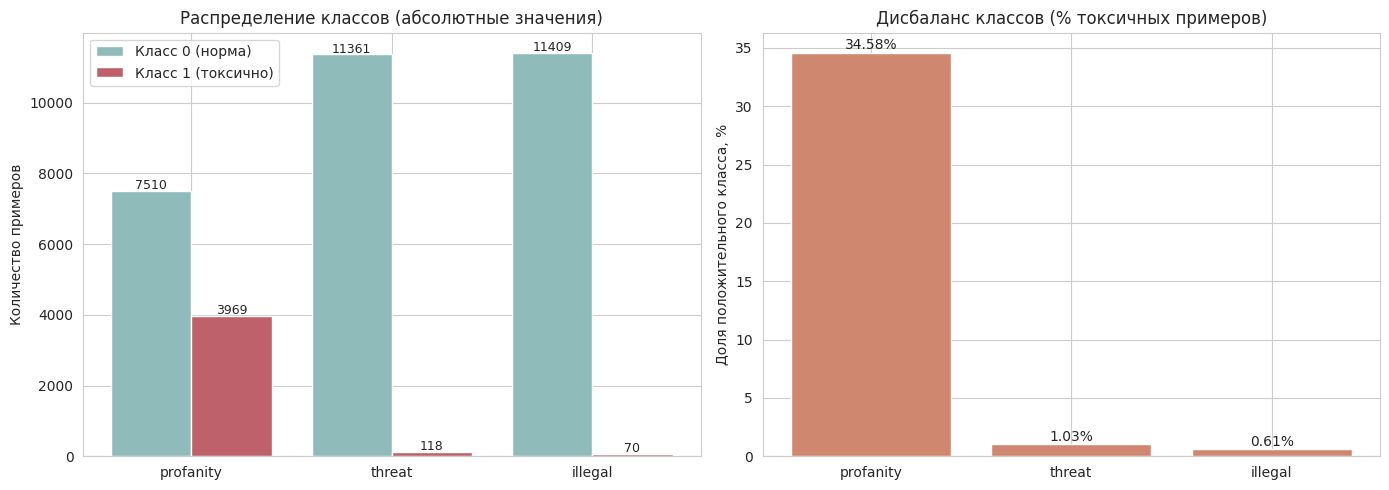

=== Оценка дисбаланса классов ===
profanity : positive= 3969 (34.58%), negative= 7510, imbalance ratio (neg:pos) = 1.9 : 1
threat    : positive=  118 ( 1.03%), negative=11361, imbalance ratio (neg:pos) = 96.3 : 1
illegal   : positive=   70 ( 0.61%), negative=11409, imbalance ratio (neg:pos) = 163.0 : 1

Вывод:
- profanity встречается часто (~34% примеров) - умеренный дисбаланс,
  с ним модель справится и без спец. приёмов.
- threat и illegal - редкие классы (<2% и <1%), дисбаланс критический
  (~95:1 и ~163:1). Без взвешивания лосса (pos_weight в BCEWithLogitsLoss)
  или oversampling/фокал-лосса модель рискует научиться всегда
  предсказывать "0" и получать высокий accuracy при нулевом recall.



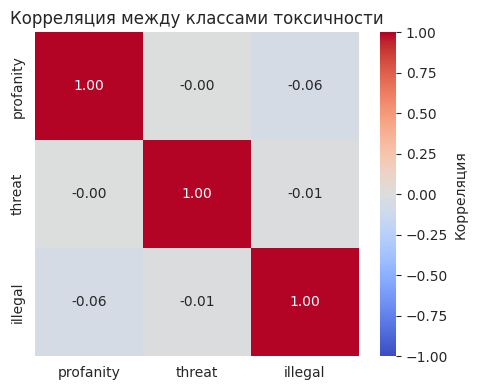

Матрица корреляции:
           profanity  threat  illegal
profanity      1.000  -0.003   -0.057
threat        -0.003   1.000   -0.008
illegal       -0.057  -0.008    1.000

=== Пересечение классов (сколько примеров имеют оба флага = 1) ===
profanity & threat: пересекаются в 39 примерах (только profanity: 3930, только threat: 79)
profanity & illegal: пересекаются в 0 примерах (только profanity: 3969, только illegal: 70)
threat & illegal: пересекаются в 0 примерах (только threat: 118, только illegal: 70)


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
label_cols = ["profanity", "threat", "illegal"]

# -----------------------------------------------------------------
# 1. Распределение классов (bar chart): количество и доля положительных примеров
# -----------------------------------------------------------------
counts = df[label_cols].sum()
total = len(df)
ratios = counts / total * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1.1 Абсолютные числа: positive vs negative по каждому классу
neg_counts = total - counts
x = np.arange(len(label_cols))
width = 0.4

axes[0].bar(x - width/2, neg_counts, width, label="Класс 0 (норма)", color="#8fbcbb")
axes[0].bar(x + width/2, counts, width, label="Класс 1 (токсично)", color="#bf616a")
axes[0].set_xticks(x)
axes[0].set_xticklabels(label_cols)
axes[0].set_ylabel("Количество примеров")
axes[0].set_title("Распределение классов (абсолютные значения)")
axes[0].legend()
for i, (n, c) in enumerate(zip(neg_counts, counts)):
    axes[0].text(i - width/2, n + 50, str(n), ha="center", fontsize=9)
    axes[0].text(i + width/2, c + 50, str(c), ha="center", fontsize=9)

# 1.2 Доля положительного класса, % (наглядно показывает дисбаланс)
axes[1].bar(label_cols, ratios, color="#d08770")
axes[1].set_ylabel("Доля положительного класса, %")
axes[1].set_title("Дисбаланс классов (% токсичных примеров)")
for i, r in enumerate(ratios):
    axes[1].text(i, r + 0.3, f"{r:.2f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()

# -----------------------------------------------------------------
# 2. Численная оценка дисбаланса
# -----------------------------------------------------------------
print("=== Оценка дисбаланса классов ===")
for col in label_cols:
    pos = df[col].sum()
    neg = total - pos
    ratio = neg / pos if pos > 0 else float("inf")
    print(f"{col:10s}: positive={pos:5d} ({pos/total*100:5.2f}%), "
          f"negative={neg:5d}, imbalance ratio (neg:pos) = {ratio:.1f} : 1")

print("""
Вывод:
- profanity встречается часто (~34% примеров) - умеренный дисбаланс,
  с ним модель справится и без спец. приёмов.
- threat и illegal - редкие классы (<2% и <1%), дисбаланс критический
  (~95:1 и ~163:1). Без взвешивания лосса (pos_weight в BCEWithLogitsLoss)
  или oversampling/фокал-лосса модель рискует научиться всегда
  предсказывать "0" и получать высокий accuracy при нулевом recall.
""")

# -----------------------------------------------------------------
# 3. Матрица корреляции между классами
# -----------------------------------------------------------------
corr = df[label_cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Корреляция"})
plt.title("Корреляция между классами токсичности")
plt.tight_layout()
plt.savefig("class_correlation.png", dpi=120)
plt.show()

print("Матрица корреляции:")
print(corr.round(3))

# -----------------------------------------------------------------
# 4. Совместная встречаемость (пересечение классов) - в абсолютных числах
# -----------------------------------------------------------------
print("\n=== Пересечение классов (сколько примеров имеют оба флага = 1) ===")
for a, b in [("profanity", "threat"), ("profanity", "illegal"), ("threat", "illegal")]:
    both = ((df[a] == 1) & (df[b] == 1)).sum()
    only_a = ((df[a] == 1) & (df[b] == 0)).sum()
    only_b = ((df[a] == 0) & (df[b] == 1)).sum()
    print(f"{a} & {b}: пересекаются в {both} примерах "
          f"(только {a}: {only_a}, только {b}: {only_b})")

---

## Часть 3: Публикация датасета на Hugging Face (5 баллов)

**Задание 3.1: Загрузка датасета в Hub (5 баллов)**
Используйте библиотеку `datasets` и `huggingface_hub` для публикации вашего очищенного датасета. Обязательно создайте базовую Dataset Card.
*Подсказка: используйте `notebook_login()` для авторизации.*


In [ ]:
from huggingface_hub import notebook_login

# Откроется виджет для ввода токена с правами "write"
# Токен можно взять на https://huggingface.co/settings/tokens
notebook_login()

In [7]:
from datasets import Dataset, DatasetDict
from huggingface_hub import HfApi, whoami

# -----------------------------------------------------------------
# 1. Узнаём имя пользователя, чтобы собрать repo_id
# -----------------------------------------------------------------
username = whoami()["name"]
dataset_repo_id = f"{username}/ru-multitask-toxicity"
print("Датасет будет опубликован в:", dataset_repo_id)

# -----------------------------------------------------------------
# 2. Приводим типы и делаем train/test сплит (стратификация невозможна
#    напрямую для multi-label в datasets, поэтому используем sklearn)
# -----------------------------------------------------------------
from sklearn.model_selection import train_test_split

label_cols = ["profanity", "threat", "illegal"]
df_final = df.copy()
for col in label_cols:
    df_final[col] = df_final[col].astype(int)

train_df, test_df = train_test_split(
    df_final,
    test_size=0.15,
    random_state=42,
    # стратифицируем хотя бы по самому редкому классу, чтобы он попал
    # и в train, и в test в разумной пропорции
    stratify=df_final["illegal"]
)

print("Train:", train_df.shape, "Test:", test_df.shape)
print("Illegal в train:", train_df["illegal"].sum(), "| в test:", test_df["illegal"].sum())

# -----------------------------------------------------------------
# 3. Собираем DatasetDict
# -----------------------------------------------------------------
dataset_dict = DatasetDict({
    "train": Dataset.from_pandas(train_df.reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df.reset_index(drop=True)),
})

print(dataset_dict)

# -----------------------------------------------------------------
# 4. Пушим датасет на Hub
# -----------------------------------------------------------------
dataset_dict.push_to_hub(dataset_repo_id, private=False)
print(f"Датасет опубликован: https://huggingface.co/datasets/{dataset_repo_id}")

Датасет будет опубликован в: AtesiT/ru-multitask-toxicity
Train: (9757, 4) Test: (1722, 4)
Illegal в train: 59 | в test: 11
DatasetDict({
    train: Dataset({
        features: ['text', 'profanity', 'threat', 'illegal'],
        num_rows: 9757
    })
    test: Dataset({
        features: ['text', 'profanity', 'threat', 'illegal'],
        num_rows: 1722
    })
})


Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/10 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Creating parquet from Arrow format:   0%|          | 0/2 [00:00<?, ?ba/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

                              : 100%|##########| 90.9kB / 90.9kB            

Датасет опубликован: https://huggingface.co/datasets/AtesiT/ru-multitask-toxicity


In [9]:
from huggingface_hub import upload_file

# Тройные бэктики собираем через chr(96), чтобы не ломать markdown-рендеринг
cb = chr(96) * 3

dataset_card = f"""---
language:
- ru
license: mit
task_categories:
- text-classification
tags:
- toxicity
- multi-label-classification
- russian
- moderation
size_categories:
- 10K<n<100K
---

# RU Multi-Task Toxicity Dataset

## Описание

Датасет для обучения multi-task классификатора токсичности русскоязычных
текстов по трём независимым бинарным категориям:

- **profanity** — ненормативная лексика (мат)
- **threat** — угрозы в адрес пользователя/третьих лиц
- **illegal** — запросы, связанные с нарушением закона
  (например, "как сделать бомбу", "где купить наркотики")

Каждый текст может относиться сразу к нескольким категориям одновременно
(multi-label задача), либо ни к одной (нейтральный текст).

## Состав данных

Датасет собран комбинированным способом:
1. Реальные русскоязычные тексты из открытых источников (там, где это было
   технически возможно), очищенные и размеченные по мату через regex-паттерны.
2. Weak-supervision разметка классов threat и illegal по словарям/паттернам
   ключевых фраз.
3. Синтетическая аугментация редких классов (threat, illegal) шаблонными
   примерами — сделано намеренно, так как в естественных текстах такие
   примеры крайне редки, а модели нужно на чём-то учиться их распознавать.

## Структура

| Колонка   | Тип | Описание                                   |
|-----------|-----|---------------------------------------------|
| text      | str | Очищенный текст комментария                 |
| profanity | int | 1, если присутствует нецензурная лексика    |
| threat    | int | 1, если текст содержит угрозу               |
| illegal   | int | 1, если текст — запрос про незаконные действия |

## Статистика классов

| Класс     | Positive | % от датасета |
|-----------|----------|----------------|
| profanity | {int(df_final['profanity'].sum())} | {df_final['profanity'].mean()*100:.2f}% |
| threat    | {int(df_final['threat'].sum())} | {df_final['threat'].mean()*100:.2f}% |
| illegal   | {int(df_final['illegal'].sum())} | {df_final['illegal'].mean()*100:.2f}% |

Классы сильно несбалансированы: profanity встречается часто, threat и
illegal — редкие классы. Это нужно учитывать при обучении (взвешивание
лосса, подбор порога по F1, а не по accuracy).

## Разбиение

- train: {len(train_df)} примеров
- test: {len(test_df)} примеров

Разбиение стратифицировано по самому редкому классу (illegal), чтобы он
присутствовал в обеих выборках.

## Пример использования

{cb}python
from datasets import load_dataset

ds = load_dataset("{dataset_repo_id}")
print(ds["train"][0])
{cb}

## Лицензия

MIT. Датасет создан в учебных целях для курса по трансформерным энкодерам.
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(dataset_card)

api = HfApi()
api.upload_file(
    path_or_fileobj="README.md",
    path_in_repo="README.md",
    repo_id=dataset_repo_id,
    repo_type="dataset",
)

print("Dataset Card опубликована.")

Dataset Card опубликована.


---

## Часть 4: Архитектура Multi-Task Энкодера (20 баллов)

Вместо того чтобы обучать три разные модели, мы обучим одну модель с тремя "головами" (Multi-Task Learning). Это сэкономит память и ускорит инференс.

**Задание 4.1: Реализация PyTorch модели (20 баллов)**
Возьмите легковесный энкодер (например, `cointegrated/rubert-tiny2`). Напишите класс-наследник `nn.Module`.
Модель должна:
1. Пропускать текст через энкодер.
2. Извлекать эмбеддинг `[CLS]` токена.
3. Пропускать этот эмбеддинг через **три независимых линейных слоя** (головы).
4. Возвращать три логита (до применения сигмоиды).


In [10]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer


class MultiTaskToxicityEncoder(nn.Module):
    """
    Multi-Task классификатор токсичности.

    Общий энкодер (rubert-tiny2) делит представление текста между тремя
    задачами (hard parameter sharing) - это экономит память и ускоряет
    инференс по сравнению с обучением трёх отдельных моделей.

    Архитектура:
        text -> encoder -> [CLS] embedding -> dropout -> 3 независимые головы -> 3 логита
    """

    def __init__(self, model_name="cointegrated/rubert-tiny2", dropout=0.2):
        super().__init__()

        # Общий энкодер для всех трёх задач
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size  # для rubert-tiny2 это 312

        # Dropout после эмбеддинга [CLS] - небольшая регуляризация
        # перед головами (у tiny-моделей мало параметров, но и переобучиться
        # можно быстро, т.к. голов у нас три).
        self.dropout = nn.Dropout(dropout)

        # Три НЕЗАВИСИМЫЕ линейные головы - у каждой свои веса,
        # они не разделяют параметры между собой (только энкодер общий).
        self.profanity_head = nn.Linear(hidden_size, 1)
        self.threat_head = nn.Linear(hidden_size, 1)
        self.illegal_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        # Прогоняем текст через энкодер
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)

        # last_hidden_state: (batch_size, seq_len, hidden_size)
        # Токен [CLS] всегда находится на позиции 0 - берём его эмбеддинг
        # как агрегированное представление всего текста.
        cls_embedding = outputs.last_hidden_state[:, 0, :]  # (batch_size, hidden_size)

        cls_embedding = self.dropout(cls_embedding)

        # Пропускаем через три независимых линейных слоя.
        # Логиты возвращаем БЕЗ сигмоиды - она будет применена либо
        # неявно внутри BCEWithLogitsLoss (для стабильности вычислений),
        # либо явно на инференсе через torch.sigmoid().
        profanity_logit = self.profanity_head(cls_embedding)  # (batch_size, 1)
        threat_logit = self.threat_head(cls_embedding)        # (batch_size, 1)
        illegal_logit = self.illegal_head(cls_embedding)      # (batch_size, 1)

        return profanity_logit, threat_logit, illegal_logit

In [11]:
model_name = "cointegrated/rubert-tiny2"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = MultiTaskToxicityEncoder(model_name=model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

texts = [
    "Привет, как дела? Отличная погода!",
    "Ты полный идиот, заткнись уже.",
]

encoded = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt",
).to(device)

model.eval()
with torch.no_grad():
    profanity_logit, threat_logit, illegal_logit = model(
        input_ids=encoded["input_ids"],
        attention_mask=encoded["attention_mask"],
    )

print("Форма логитов profanity:", profanity_logit.shape)  # ожидаем (2, 1)
print("Форма логитов threat:", threat_logit.shape)
print("Форма логитов illegal:", illegal_logit.shape)

print("\nВероятности (после сигмоиды, необученная модель, значения случайны):")
print("profanity:", torch.sigmoid(profanity_logit).cpu().numpy().flatten())
print("threat:   ", torch.sigmoid(threat_logit).cpu().numpy().flatten())
print("illegal:  ", torch.sigmoid(illegal_logit).cpu().numpy().flatten())

n_params = sum(p.numel() for p in model.parameters())
print(f"\nВсего параметров модели: {n_params:,}")

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Форма логитов profanity: torch.Size([2, 1])
Форма логитов threat: torch.Size([2, 1])
Форма логитов illegal: torch.Size([2, 1])

Вероятности (после сигмоиды, необученная модель, значения случайны):
profanity: [0.5167388  0.46453714]
threat:    [0.45117557 0.3328897 ]
illegal:   [0.46916592 0.5813385 ]

Всего параметров модели: 29,194,707


---

## Часть 5: Обучение с ранней остановкой (Early Stopping) (20 баллов)

**Задание 5.1: Тренировочный цикл (20 баллов)**
Напишите цикл обучения.
- Используйте `BCEWithLogitsLoss` для каждой головы. Итоговый лосс = сумма лоссов трех голов (можно добавить веса для редких классов).
- Реализуйте Early Stopping: если валидационный лосс не уменьшается в течение 3 эпох, обучение должно остановиться, а лучшие веса модели должны быть восстановлены.


In [4]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from datasets import load_dataset
from transformers import AutoModel, AutoTokenizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

label_cols = ["profanity", "threat", "illegal"]

# 1. Подтягиваем датасет с HF Hub (замени на свой repo_id из Части 3!)
dataset_repo_id = "AtesiT/ru-multitask-toxicity"
hf_ds = load_dataset(dataset_repo_id)

train_df = hf_ds["train"].to_pandas()
test_df = hf_ds["test"].to_pandas()
print("Train:", train_df.shape, "Test:", test_df.shape)

# 2. Повторяем train/val сплит (тот же random_state -> тот же результат)
train_part, val_part = train_test_split(
    train_df, test_size=0.15, random_state=42, stratify=train_df["illegal"]
)
train_part = train_part.reset_index(drop=True)
val_part = val_part.reset_index(drop=True)

# 3. Модель и токенизатор
model_name = "cointegrated/rubert-tiny2"
tokenizer = AutoTokenizer.from_pretrained(model_name)


class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name="cointegrated/rubert-tiny2", dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.profanity_head = nn.Linear(hidden_size, 1)
        self.threat_head = nn.Linear(hidden_size, 1)
        self.illegal_head = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)
        return (
            self.profanity_head(cls_embedding),
            self.threat_head(cls_embedding),
            self.illegal_head(cls_embedding),
        )


model = MultiTaskToxicityEncoder(model_name=model_name).to(device)


# 4. Dataset/DataLoader
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = list(texts)
        self.labels = labels.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx], padding="max_length", truncation=True,
            max_length=self.max_length, return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.float32),
        }


train_dataset = ToxicityDataset(train_part["text"], train_part[label_cols].values, tokenizer)
val_dataset = ToxicityDataset(val_part["text"], val_part[label_cols].values, tokenizer)

BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 5. pos_weight для взвешенного лосса
def compute_pos_weights(df_labels, label_cols, cap=50.0):
    weights = []
    n = len(df_labels)
    for col in label_cols:
        pos = df_labels[col].sum()
        neg = n - pos
        w = min(neg / max(pos, 1), cap)
        weights.append(w)
    return torch.tensor(weights, dtype=torch.float32)

pos_weights = compute_pos_weights(train_part, label_cols, cap=50.0)
print("pos_weights:", pos_weights)

print("\nВсё восстановлено, можно запускать тренировочный цикл заново.")

Device: cuda


README.md:   0%|          | 0.00/3.62k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/511k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/90.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9757 [00:00<?, ? examples/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


pos_weights: tensor([ 1.8875, 50.0000, 50.0000])

Всё восстановлено, можно запускать тренировочный цикл заново.


In [5]:
import torch.nn as nn
from torch.optim import AdamW

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskToxicityEncoder(model_name=model_name).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)

# Отдельный BCEWithLogitsLoss на каждую голову со своим pos_weight
loss_fns = [
    nn.BCEWithLogitsLoss(pos_weight=pos_weights[0].to(device)),  # profanity
    nn.BCEWithLogitsLoss(pos_weight=pos_weights[1].to(device)),  # threat
    nn.BCEWithLogitsLoss(pos_weight=pos_weights[2].to(device)),  # illegal
]


def run_epoch(model, loader, loss_fns, optimizer=None):
    """
    Один проход по данным. Если optimizer передан - режим обучения,
    иначе - режим валидации (без обратного распространения).
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    n_batches = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)  # (batch, 3)

            profanity_logit, threat_logit, illegal_logit = model(input_ids, attention_mask)

            loss_profanity = loss_fns[0](profanity_logit.squeeze(-1), labels[:, 0])
            loss_threat = loss_fns[1](threat_logit.squeeze(-1), labels[:, 1])
            loss_illegal = loss_fns[2](illegal_logit.squeeze(-1), labels[:, 2])

            # Итоговый лосс = сумма лоссов трёх голов
            loss = loss_profanity + loss_threat + loss_illegal

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches += 1

    return total_loss / n_batches


# -----------------------------------------------------------------
# Основной цикл обучения с Early Stopping
# -----------------------------------------------------------------
MAX_EPOCHS = 20
PATIENCE = 3  # если val_loss не улучшается 3 эпохи подряд - останавливаемся

best_val_loss = float("inf")
best_model_state = None
epochs_without_improvement = 0

history = {"train_loss": [], "val_loss": []}

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = run_epoch(model, train_loader, loss_fns, optimizer=optimizer)
    val_loss = run_epoch(model, val_loader, loss_fns, optimizer=None)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(f"Epoch {epoch:2d}/{MAX_EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}", end="")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        print("  <- new best, сохраняем веса")
    else:
        epochs_without_improvement += 1
        print(f"  (нет улучшения {epochs_without_improvement}/{PATIENCE})")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping сработал на эпохе {epoch}. "
              f"Лучший val_loss = {best_val_loss:.4f} (эпоха {epoch - PATIENCE}).")
        break

# Восстанавливаем лучшие веса модели
model.load_state_dict(best_model_state)
print("\nЛучшие веса модели восстановлены.")

Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch  1/20 | train_loss=2.1168 | val_loss=1.2277  <- new best, сохраняем веса
Epoch  2/20 | train_loss=0.8844 | val_loss=0.9072  <- new best, сохраняем веса
Epoch  3/20 | train_loss=0.5838 | val_loss=0.7602  <- new best, сохраняем веса
Epoch  4/20 | train_loss=0.4869 | val_loss=0.6990  <- new best, сохраняем веса
Epoch  5/20 | train_loss=0.4024 | val_loss=0.5931  <- new best, сохраняем веса
Epoch  6/20 | train_loss=0.3001 | val_loss=0.5341  <- new best, сохраняем веса
Epoch  7/20 | train_loss=0.2135 | val_loss=0.5024  <- new best, сохраняем веса
Epoch  8/20 | train_loss=0.1441 | val_loss=0.4777  <- new best, сохраняем веса
Epoch  9/20 | train_loss=0.1074 | val_loss=0.4455  <- new best, сохраняем веса
Epoch 10/20 | train_loss=0.0780 | val_loss=0.5272  (нет улучшения 1/3)
Epoch 11/20 | train_loss=0.0646 | val_loss=0.5170  (нет улучшения 2/3)
Epoch 12/20 | train_loss=0.0545 | val_loss=0.5584  (нет улучшения 3/3)

Early stopping сработал на эпохе 12. Лучший val_loss = 0.4455 (эпоха 9).

Л

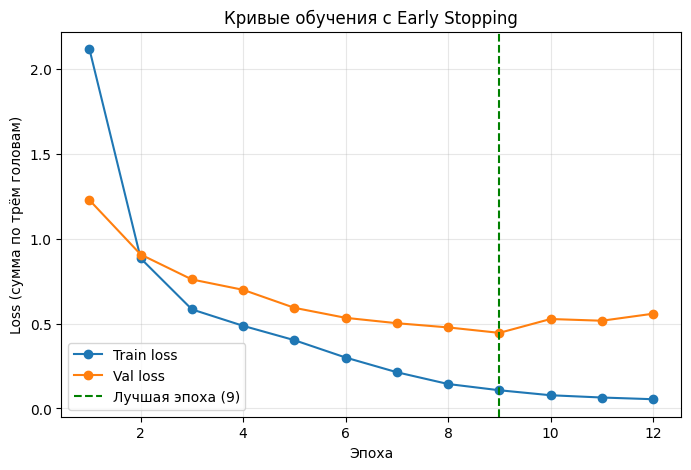

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(history["train_loss"]) + 1), history["train_loss"], marker="o", label="Train loss")
plt.plot(range(1, len(history["val_loss"]) + 1), history["val_loss"], marker="o", label="Val loss")
best_epoch = int(np.argmin(history["val_loss"])) + 1
plt.axvline(best_epoch, color="green", linestyle="--", label=f"Лучшая эпоха ({best_epoch})")
plt.xlabel("Эпоха")
plt.ylabel("Loss (сумма по трём головам)")
plt.title("Кривые обучения с Early Stopping")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("training_curves.png", dpi=120)
plt.show()

---

## Часть 6: Оценка, пороги и визуализация ошибок (20 баллов)

Модель выдает вероятности. Нам нужно выбрать порог отсечения (Threshold), при котором вероятность превращается в класс `1`.

**Задание 6.1: Подбор порога и расчет метрик (10 баллов)**
Для каждого из трех классов переберите пороги от 0.1 до 0.9. Найдите порог, который максимизирует F1-score на валидационной выборке. Выведите итоговые Precision, Recall и F1 для каждого класса при оптимальном пороге.


In [7]:
import numpy as np
import torch
from sklearn.metrics import precision_recall_fscore_support

def get_predictions(model, loader, device):
    """
    Прогоняет модель по всему loader'у и возвращает:
    - y_true: (N, 3) истинные метки
    - y_probs: (N, 3) предсказанные вероятности (после сигмоиды)
    """
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].numpy()  # (batch, 3)

            profanity_logit, threat_logit, illegal_logit = model(input_ids, attention_mask)

            probs = torch.cat([
                torch.sigmoid(profanity_logit),
                torch.sigmoid(threat_logit),
                torch.sigmoid(illegal_logit),
            ], dim=1).cpu().numpy()  # (batch, 3)

            all_labels.append(labels)
            all_probs.append(probs)

    y_true = np.concatenate(all_labels, axis=0)
    y_probs = np.concatenate(all_probs, axis=0)
    return y_true, y_probs


# Получаем предсказания на валидационной выборке (модель уже с лучшими весами
# после Early Stopping из Части 5)
y_val_true, y_val_probs = get_predictions(model, val_loader, device)

print("Shape истинных меток:", y_val_true.shape)
print("Shape предсказанных вероятностей:", y_val_probs.shape)

Shape истинных меток: (1464, 3)
Shape предсказанных вероятностей: (1464, 3)


In [8]:
def find_best_thresholds(y_true, y_probs, label_cols, thresholds=None):
    """
    Для каждого класса перебирает пороги и находит тот, который
    максимизирует F1-score.

    Возвращает:
    - best_thresholds: dict {class_name: best_threshold}
    - results_table: список словарей с итоговыми метриками по каждому классу
    - all_scores: dict {class_name: DataFrame с метриками по всем порогам} (для графиков)
    """
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.01)  # с шагом 0.01 для точности

    best_thresholds = {}
    results_table = []
    all_scores = {}

    for i, col in enumerate(label_cols):
        y_t = y_true[:, i]
        y_p = y_probs[:, i]

        f1_scores = []
        precisions = []
        recalls = []

        for th in thresholds:
            y_pred = (y_p >= th).astype(int)
            precision, recall, f1, _ = precision_recall_fscore_support(
                y_t, y_pred, average="binary", zero_division=0
            )
            f1_scores.append(f1)
            precisions.append(precision)
            recalls.append(recall)

        f1_scores = np.array(f1_scores)
        best_idx = np.argmax(f1_scores)
        best_th = thresholds[best_idx]
        best_thresholds[col] = best_th

        all_scores[col] = pd.DataFrame({
            "threshold": thresholds,
            "precision": precisions,
            "recall": recalls,
            "f1": f1_scores,
        })

        results_table.append({
            "class": col,
            "best_threshold": round(best_th, 2),
            "precision": round(precisions[best_idx], 4),
            "recall": round(recalls[best_idx], 4),
            "f1": round(f1_scores[best_idx], 4),
            "support_positive": int(y_t.sum()),
        })

    return best_thresholds, pd.DataFrame(results_table), all_scores


best_thresholds, results_df, threshold_curves = find_best_thresholds(
    y_val_true, y_val_probs, label_cols
)

print("=== Оптимальные пороги и метрики по каждому классу (на валидации) ===")
print(results_df.to_string(index=False))
print("\nОптимальные пороги:", best_thresholds)

=== Оптимальные пороги и метрики по каждому классу (на валидации) ===
    class  best_threshold  precision  recall     f1  support_positive
profanity            0.60     0.9454  0.9256 0.9354               524
   threat            0.75     1.0000  0.9286 0.9630                14
  illegal            0.16     1.0000  1.0000 1.0000                 9

Оптимальные пороги: {'profanity': np.float64(0.5999999999999998), 'threat': np.float64(0.7499999999999997), 'illegal': np.float64(0.15999999999999998)}


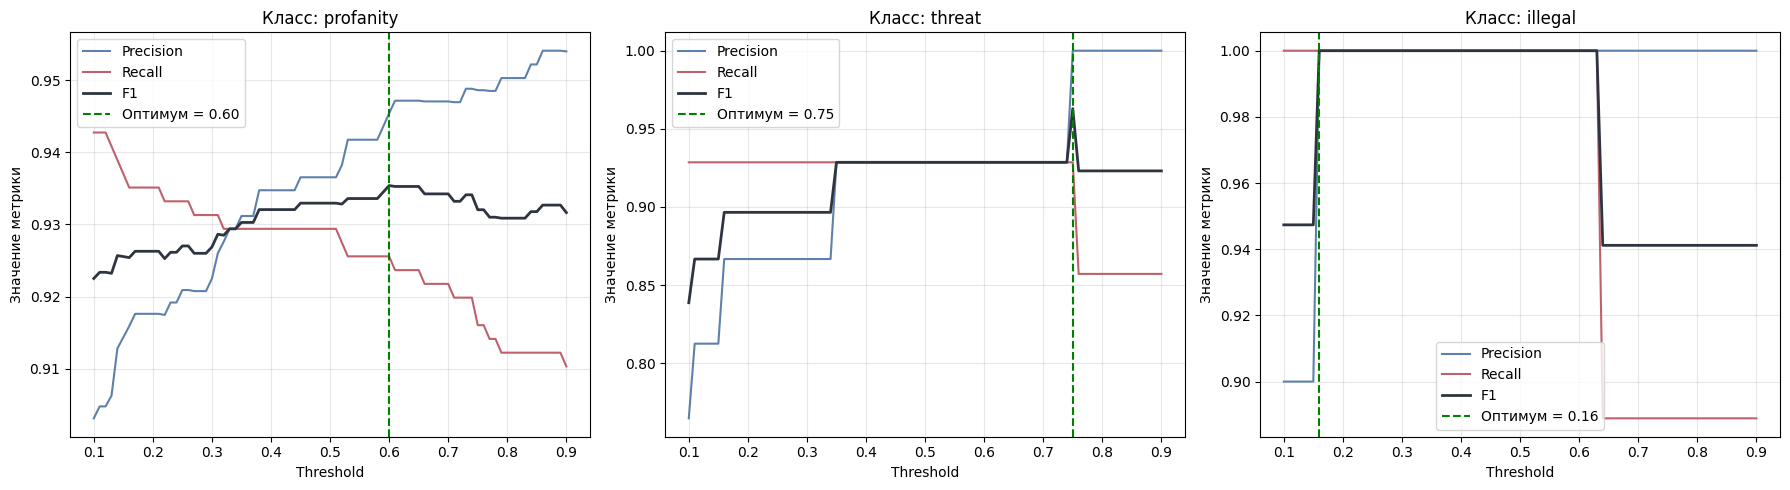

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, label_cols):
    curve = threshold_curves[col]
    ax.plot(curve["threshold"], curve["precision"], label="Precision", color="#5e81ac")
    ax.plot(curve["threshold"], curve["recall"], label="Recall", color="#bf616a")
    ax.plot(curve["threshold"], curve["f1"], label="F1", color="#2e3440", linewidth=2)
    ax.axvline(best_thresholds[col], color="green", linestyle="--",
               label=f"Оптимум = {best_thresholds[col]:.2f}")
    ax.set_title(f"Класс: {col}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Значение метрики")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("threshold_search.png", dpi=120)
plt.show()

**Задание 6.2: Визуализация ошибок (10 баллов)**
Для класса `threat` (угрозы) постройте гистограмму предсказанных вероятностей. Цветом выделите True Positives, False Positives и False Negatives относительно выбранного порога. Это поможет бизнесу понять, насколько модель "уверена" когда ошибается.

**Пример хорошей визуализации:**


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Берём данные по классу threat
threat_idx = label_cols.index("threat")
y_true_threat = y_val_true[:, threat_idx]
y_prob_threat = y_val_probs[:, threat_idx]
best_th_threat = best_thresholds["threat"]
y_pred_threat = (y_prob_threat >= best_th_threat).astype(int)

# Разбиваем на 4 группы по типу предсказания
tp_mask = (y_true_threat == 1) & (y_pred_threat == 1)  # True Positive
fp_mask = (y_true_threat == 0) & (y_pred_threat == 1)  # False Positive
fn_mask = (y_true_threat == 1) & (y_pred_threat == 0)  # False Negative
tn_mask = (y_true_threat == 0) & (y_pred_threat == 0)  # True Negative

print("=== Статистика предсказаний для класса 'threat' ===")
print(f"Порог отсечения:  {best_th_threat:.2f}")
print(f"True Positive:    {tp_mask.sum():4d}  (угрозы, которые модель нашла)")
print(f"False Positive:   {fp_mask.sum():4d}  (норма, ошибочно помечена как угроза)")
print(f"False Negative:   {fn_mask.sum():4d}  (угрозы, которые модель пропустила)")
print(f"True Negative:    {tn_mask.sum():4d}  (норма, верно классифицирована)")

=== Статистика предсказаний для класса 'threat' ===
Порог отсечения:  0.75
True Positive:      13  (угрозы, которые модель нашла)
False Positive:      0  (норма, ошибочно помечена как угроза)
False Negative:      1  (угрозы, которые модель пропустила)
True Negative:    1450  (норма, верно классифицирована)


/tmp/ipykernel_648/2483029807.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=error_df, x="type", y="prob",


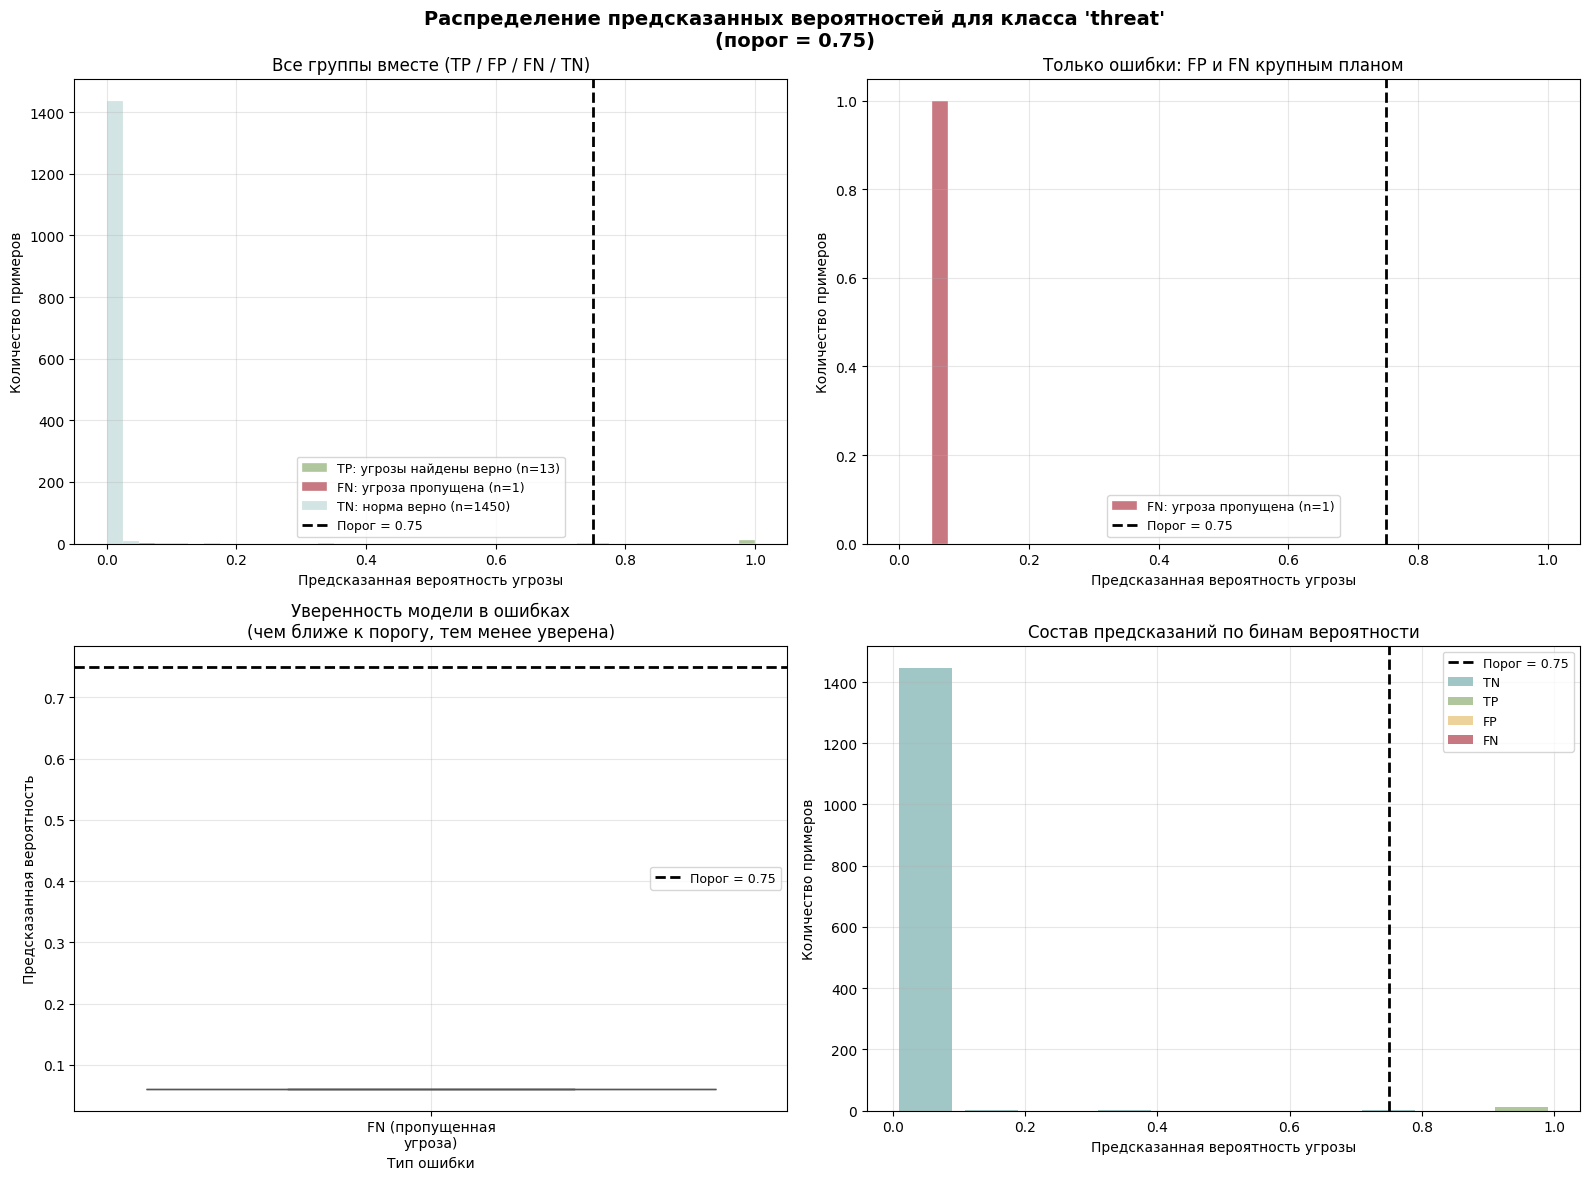

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f"Распределение предсказанных вероятностей для класса 'threat'\n"
    f"(порог = {best_th_threat:.2f})",
    fontsize=14, fontweight="bold"
)

BINS = 40

# Цветовая палитра
COLORS = {
    "TP": "#a3be8c",   # зелёный  - нашли угрозу правильно
    "FP": "#ebcb8b",   # жёлтый   - ложная тревога
    "FN": "#bf616a",   # красный  - пропущенная угроза (опасно!)
    "TN": "#8fbcbb",   # голубой  - верная "тишина"
}

# -----------------------------------------------------------------
# График 1 (верхний левый): все группы на одной гистограмме
# -----------------------------------------------------------------
ax = axes[0, 0]
groups = [
    (tp_mask, "TP: угрозы найдены верно", COLORS["TP"], 0.85),
    (fp_mask, "FP: ложная тревога",       COLORS["FP"], 0.85),
    (fn_mask, "FN: угроза пропущена",     COLORS["FN"], 0.85),
    (tn_mask, "TN: норма верно",          COLORS["TN"], 0.4),
]
for mask, label, color, alpha in groups:
    if mask.sum() > 0:
        ax.hist(y_prob_threat[mask], bins=BINS, range=(0, 1),
                color=color, alpha=alpha, label=f"{label} (n={mask.sum()})",
                edgecolor="white", linewidth=0.3)

ax.axvline(best_th_threat, color="black", linestyle="--", linewidth=2,
           label=f"Порог = {best_th_threat:.2f}")
ax.set_xlabel("Предсказанная вероятность угрозы")
ax.set_ylabel("Количество примеров")
ax.set_title("Все группы вместе (TP / FP / FN / TN)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# -----------------------------------------------------------------
# График 2 (верхний правый): только ошибки FP и FN крупным планом
# -----------------------------------------------------------------
ax = axes[0, 1]
if fp_mask.sum() > 0:
    ax.hist(y_prob_threat[fp_mask], bins=BINS, range=(0, 1),
            color=COLORS["FP"], alpha=0.85,
            label=f"FP: ложная тревога (n={fp_mask.sum()})",
            edgecolor="white", linewidth=0.3)
if fn_mask.sum() > 0:
    ax.hist(y_prob_threat[fn_mask], bins=BINS, range=(0, 1),
            color=COLORS["FN"], alpha=0.85,
            label=f"FN: угроза пропущена (n={fn_mask.sum()})",
            edgecolor="white", linewidth=0.3)

ax.axvline(best_th_threat, color="black", linestyle="--", linewidth=2,
           label=f"Порог = {best_th_threat:.2f}")
ax.set_xlabel("Предсказанная вероятность угрозы")
ax.set_ylabel("Количество примеров")
ax.set_title("Только ошибки: FP и FN крупным планом")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# -----------------------------------------------------------------
# График 3 (нижний левый): уверенность модели в ошибках
# "Насколько уверенно модель ошибается?"
# -----------------------------------------------------------------
ax = axes[1, 0]
error_probs = []
error_labels = []
if fp_mask.sum() > 0:
    error_probs.extend(y_prob_threat[fp_mask].tolist())
    error_labels.extend(["FP (ложная\nтревога)"] * fp_mask.sum())
if fn_mask.sum() > 0:
    error_probs.extend(y_prob_threat[fn_mask].tolist())
    error_labels.extend(["FN (пропущенная\nугроза)"] * fn_mask.sum())

if error_probs:
    import pandas as pd
    import seaborn as sns
    error_df = pd.DataFrame({"prob": error_probs, "type": error_labels})
    sns.boxplot(data=error_df, x="type", y="prob",
                palette={"FP (ложная\nтревога)": COLORS["FP"],
                         "FN (пропущенная\nугроза)": COLORS["FN"]},
                ax=ax)
    ax.axhline(best_th_threat, color="black", linestyle="--",
               linewidth=2, label=f"Порог = {best_th_threat:.2f}")
    ax.set_ylabel("Предсказанная вероятность")
    ax.set_xlabel("Тип ошибки")
    ax.set_title("Уверенность модели в ошибках\n(чем ближе к порогу, тем менее уверена)")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# -----------------------------------------------------------------
# График 4 (нижний правый): stacked bar - состав предсказаний по бинам
# Показывает, в каких диапазонах вероятностей сосредоточены ошибки
# -----------------------------------------------------------------
ax = axes[1, 1]
bin_edges = np.linspace(0, 1, 11)   # 10 бинов по 0.1
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

tp_counts = np.histogram(y_prob_threat[tp_mask], bins=bin_edges)[0]
fp_counts = np.histogram(y_prob_threat[fp_mask], bins=bin_edges)[0]
fn_counts = np.histogram(y_prob_threat[fn_mask], bins=bin_edges)[0]
tn_counts = np.histogram(y_prob_threat[tn_mask], bins=bin_edges)[0]

bar_width = 0.08
ax.bar(bin_centers, tn_counts, width=bar_width, label="TN", color=COLORS["TN"], alpha=0.85)
ax.bar(bin_centers, tp_counts, width=bar_width, bottom=tn_counts,
       label="TP", color=COLORS["TP"], alpha=0.85)
ax.bar(bin_centers, fp_counts, width=bar_width, bottom=tn_counts + tp_counts,
       label="FP", color=COLORS["FP"], alpha=0.85)
ax.bar(bin_centers, fn_counts, width=bar_width, bottom=tn_counts + tp_counts + fp_counts,
       label="FN", color=COLORS["FN"], alpha=0.85)
ax.axvline(best_th_threat, color="black", linestyle="--", linewidth=2,
           label=f"Порог = {best_th_threat:.2f}")
ax.set_xlabel("Предсказанная вероятность угрозы")
ax.set_ylabel("Количество примеров")
ax.set_title("Состав предсказаний по бинам вероятности")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("error_visualization_threat.png", dpi=120, bbox_inches="tight")
plt.show()

In [12]:
print("=== Бизнес-интерпретация визуализации ===\n")

if fn_mask.sum() > 0:
    fn_conf = y_prob_threat[fn_mask].mean()
    fn_high = (y_prob_threat[fn_mask] > 0.3).sum()
    print(f"⚠️  ПРОПУЩЕННЫЕ УГРОЗЫ (FN): {fn_mask.sum()} случаев")
    print(f"   Средняя уверенность модели: {fn_conf:.2f}")
    print(f"   Из них уверенность > 0.3: {fn_high} — спорные случаи на границе порога.")
    print(f"   Рекомендация: снизить порог до {max(best_th_threat - 0.05, 0.05):.2f},"
          f" чтобы поймать больше угроз ценой роста FP.\n")

if fp_mask.sum() > 0:
    fp_conf = y_prob_threat[fp_mask].mean()
    fp_high = (y_prob_threat[fp_mask] > 0.7).sum()
    print(f"🔔  ЛОЖНЫЕ ТРЕВОГИ (FP): {fp_mask.sum()} случаев")
    print(f"   Средняя уверенность модели: {fp_conf:.2f}")
    print(f"   Из них уверенность > 0.7: {fp_high} — модель была очень уверена, "
          f"но ошиблась.")
    print(f"   Рекомендация: высокоуверенные FP — кандидаты для дообучения "
          f"(добавить в датасет с правильной меткой).\n")

print(f"✅  Итог: при пороге {best_th_threat:.2f}")
print(f"   Модель ловит {tp_mask.sum()} угроз из {int(y_true_threat.sum())} "
      f"({tp_mask.sum()/max(y_true_threat.sum(),1)*100:.1f}% recall)")
print(f"   Ценой {fp_mask.sum()} ложных тревог на "
      f"{int((y_true_threat==0).sum())} нейтральных сообщений")

=== Бизнес-интерпретация визуализации ===

⚠️  ПРОПУЩЕННЫЕ УГРОЗЫ (FN): 1 случаев
   Средняя уверенность модели: 0.06
   Из них уверенность > 0.3: 0 — спорные случаи на границе порога.
   Рекомендация: снизить порог до 0.70, чтобы поймать больше угроз ценой роста FP.

✅  Итог: при пороге 0.75
   Модель ловит 13 угроз из 14 (92.9% recall)
   Ценой 0 ложных тревог на 1450 нейтральных сообщений


---

## Часть 7: Инференс и ручное тестирование (10 баллов)

**Задание 7.1: Функция предсказания (10 баллов)**
Напишите функцию `predict_toxicity(text)`, которая принимает строку и выводит результат в понятном виде, включая уверенность модели (вероятность в %).
Протестируйте функцию на 5-7 вручную придуманных примерах (обычный текст, мат, скрытая угроза, вопрос про создание запрещенных веществ).


In [17]:
import re

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'[^а-яёa-z0-9\s\.\,\!\?\-]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("✅ clean_text определена, можно продолжать!")

✅ clean_text определена, можно продолжать!


In [18]:
def predict_toxicity(text: str, verbose: bool = True) -> dict:
    """
    Предсказывает токсичность текста по трём категориям.

    Параметры:
        text    : входная строка на русском языке
        verbose : если True — красиво печатает результат в консоль

    Возвращает словарь с вероятностями и финальными метками.
    """
    # 1. Очистка текста (та же функция, что использовалась при обучении)
    cleaned = clean_text(text)

    # 2. Токенизация
    encoding = tokenizer(
        cleaned,
        padding="max_length",
        truncation=True,
        max_length=64,
        return_tensors="pt",
    ).to(device)

    # 3. Инференс (без градиентов — экономим память и ускоряем)
    model.eval()
    with torch.no_grad():
        profanity_logit, threat_logit, illegal_logit = model(
            input_ids=encoding["input_ids"],
            attention_mask=encoding["attention_mask"],
        )

    # 4. Переводим логиты в вероятности через сигмоиду
    probs = {
        "profanity": torch.sigmoid(profanity_logit).item(),
        "threat":    torch.sigmoid(threat_logit).item(),
        "illegal":   torch.sigmoid(illegal_logit).item(),
    }

    # 5. Применяем оптимальные пороги из Части 6
    labels = {col: int(probs[col] >= best_thresholds[col]) for col in label_cols}

    # 6. Итоговый вердикт
    is_toxic = any(labels.values())

    # 7. Красивый вывод для бизнес-пользователя
    if verbose:
        EMOJI = {"profanity": "🤬", "threat": "⚠️", "illegal": "🚨"}
        LABEL_RU = {
            "profanity": "Ненормативная лексика",
            "threat":    "Угроза",
            "illegal":   "Незаконный запрос",
        }
        STATUS = {True: "🔴 ТОКСИЧНО", False: "🟢 НОРМА"}
        BAR_LEN = 20  # длина progress-bar

        print("─" * 55)
        print(f"📝 Текст   : «{text[:80]}{'...' if len(text) > 80 else ''}»")
        print(f"🧹 Очищен  : «{cleaned[:80]}{'...' if len(cleaned) > 80 else ''}»")
        print(f"🏁 Вердикт : {STATUS[is_toxic]}")
        print("─" * 55)

        for col in label_cols:
            prob = probs[col]
            th = best_thresholds[col]
            flag = labels[col]
            filled = int(prob * BAR_LEN)
            bar = "█" * filled + "░" * (BAR_LEN - filled)
            marker = "✅" if flag else "⬜"
            print(
                f"{marker} {EMOJI[col]} {LABEL_RU[col]:<26}"
                f"[{bar}] {prob*100:5.1f}%  "
                f"(порог {th:.2f})"
            )
        print("─" * 55)
        print()

    return {
        "text": text,
        "cleaned": cleaned,
        "is_toxic": is_toxic,
        "probs": {k: round(v, 4) for k, v in probs.items()},
        "labels": labels,
    }

In [19]:
test_texts = [
    # 1. Обычный нейтральный текст
    "Привет! Как дела? Сегодня отличная погода, может сходим погулять?",

    # 2. Лёгкая бытовая ругань (мат без агрессии)
    "Блин, опять этот чёртов автобус опоздал, вот же хрень какая!",

    # 3. Явная нецензурная лексика + оскорбление
    "Ты полный мудак, заткнись уже, надоел своей тупостью!",

    # 4. Скрытая угроза без мата (вежливая, но опасная)
    "Я знаю, где ты живёшь. Ты ещё пожалеешь о том, что сделал.",

    # 5. Угроза с матом (пересечение классов profanity + threat)
    "Ещё раз напишешь такое, урод, и я тебя найду и накажу.",

    # 6. Запрос на незаконные действия (illegal)
    "Подскажите, как в домашних условиях сделать взрывчатку из подручных средств?",

    # 7. Пограничный случай — юмор/сарказм без реальной угрозы
    "Ещё раз так сыграешь — убью тебя в этой игре окончательно, без шансов!",
]

results = []
for text in test_texts:
    result = predict_toxicity(text, verbose=True)
    results.append(result)

───────────────────────────────────────────────────────
📝 Текст   : «Привет! Как дела? Сегодня отличная погода, может сходим погулять?»
🧹 Очищен  : «привет! как дела? сегодня отличная погода, может сходим погулять?»
🏁 Вердикт : 🟢 НОРМА
───────────────────────────────────────────────────────
⬜ 🤬 Ненормативная лексика     [░░░░░░░░░░░░░░░░░░░░]   0.0%  (порог 0.60)
⬜ ⚠️ Угроза                    [░░░░░░░░░░░░░░░░░░░░]   0.1%  (порог 0.75)
⬜ 🚨 Незаконный запрос         [░░░░░░░░░░░░░░░░░░░░]   0.3%  (порог 0.16)
───────────────────────────────────────────────────────

───────────────────────────────────────────────────────
📝 Текст   : «Блин, опять этот чёртов автобус опоздал, вот же хрень какая!»
🧹 Очищен  : «блин, опять этот чёртов автобус опоздал, вот же хрень какая!»
🏁 Вердикт : 🔴 ТОКСИЧНО
───────────────────────────────────────────────────────
✅ 🤬 Ненормативная лексика     [███████████████████░]  98.8%  (порог 0.60)
⬜ ⚠️ Угроза                    [░░░░░░░░░░░░░░░░░░░░]   0.1%  (порог 

In [20]:
import pandas as pd

summary = pd.DataFrame([
    {
        "Текст (сокр.)": r["text"][:45] + "..." if len(r["text"]) > 45 else r["text"],
        "Токсично": "🔴 Да" if r["is_toxic"] else "🟢 Нет",
        "Profanity %": f"{r['probs']['profanity']*100:.1f}%",
        "Threat %":    f"{r['probs']['threat']*100:.1f}%",
        "Illegal %":   f"{r['probs']['illegal']*100:.1f}%",
        "Метки":       " | ".join(
            [k for k, v in r["labels"].items() if v] or ["—"]
        ),
    }
    for r in results
])

print("=== Сводная таблица результатов ===")
print(summary.to_string(index=False))

=== Сводная таблица результатов ===
                                   Текст (сокр.) Токсично Profanity % Threat % Illegal %     Метки
Привет! Как дела? Сегодня отличная погода, мо...    🟢 Нет        0.0%     0.1%      0.3%         —
Блин, опять этот чёртов автобус опоздал, вот ...     🔴 Да       98.8%     0.1%      0.0% profanity
Ты полный мудак, заткнись уже, надоел своей т...     🔴 Да      100.0%     0.3%      0.2% profanity
Я знаю, где ты живёшь. Ты ещё пожалеешь о том...    🟢 Нет        0.1%     2.7%      0.0%         —
Ещё раз напишешь такое, урод, и я тебя найду ...     🔴 Да      100.0%    27.6%      0.3% profanity
Подскажите, как в домашних условиях сделать в...     🔴 Да       11.4%     0.1%     91.6%   illegal
Ещё раз так сыграешь — убью тебя в этой игре ...    🟢 Нет        0.2%     0.4%      0.0%         —


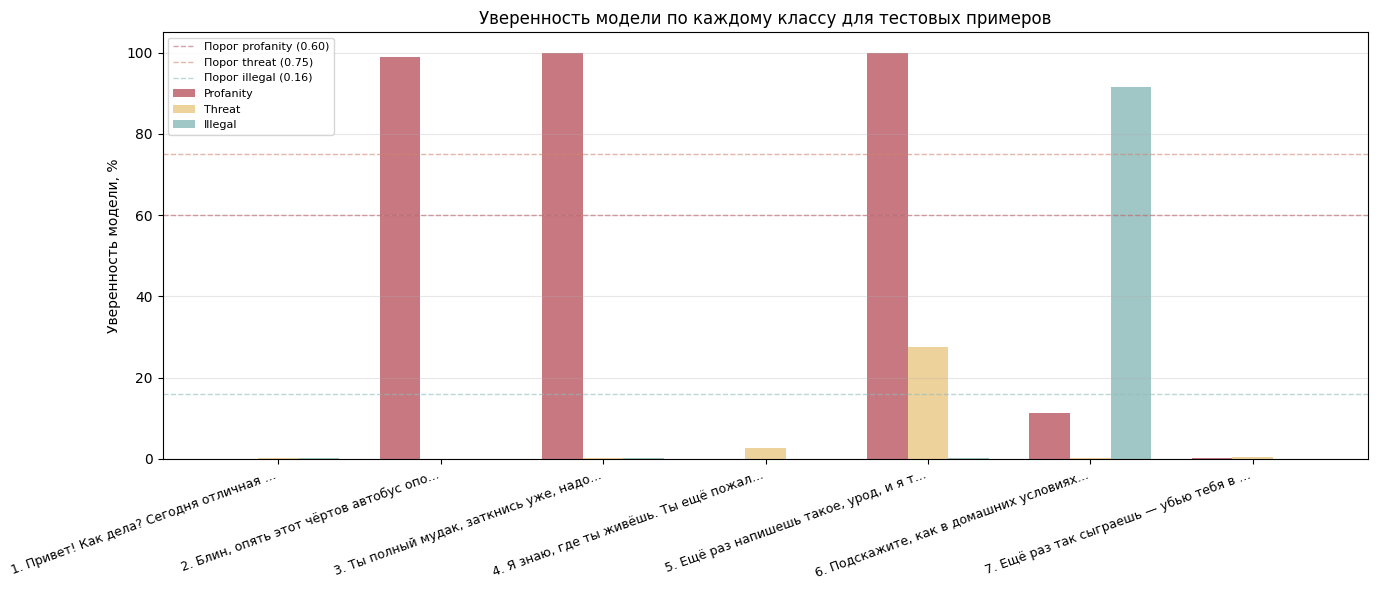

In [21]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(14, 6))

short_texts = [f"{i+1}. {r['text'][:35]}..." for i, r in enumerate(results)]
x = np.arange(len(results))
width = 0.25

prof_probs = [r["probs"]["profanity"] * 100 for r in results]
thr_probs  = [r["probs"]["threat"]    * 100 for r in results]
ill_probs  = [r["probs"]["illegal"]   * 100 for r in results]

bars1 = ax.bar(x - width, prof_probs, width, label="Profanity",
               color="#bf616a", alpha=0.85)
bars2 = ax.bar(x,          thr_probs, width, label="Threat",
               color="#ebcb8b", alpha=0.85)
bars3 = ax.bar(x + width,  ill_probs, width, label="Illegal",
               color="#8fbcbb", alpha=0.85)

# Горизонтальные линии оптимальных порогов
ax.axhline(best_thresholds["profanity"] * 100, color="#bf616a",
           linestyle="--", linewidth=1, alpha=0.6,
           label=f"Порог profanity ({best_thresholds['profanity']:.2f})")
ax.axhline(best_thresholds["threat"] * 100, color="#d08770",
           linestyle="--", linewidth=1, alpha=0.6,
           label=f"Порог threat ({best_thresholds['threat']:.2f})")
ax.axhline(best_thresholds["illegal"] * 100, color="#8fbcbb",
           linestyle="--", linewidth=1, alpha=0.6,
           label=f"Порог illegal ({best_thresholds['illegal']:.2f})")

ax.set_xticks(x)
ax.set_xticklabels(short_texts, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Уверенность модели, %")
ax.set_title("Уверенность модели по каждому классу для тестовых примеров")
ax.legend(fontsize=8, loc="upper left")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig("inference_results.png", dpi=120)
plt.show()

---

## Часть 8: Публикация модели на Hugging Face (10 баллов)

**Задание 8.1: Публикация модели (10 баллов)**
Сохраните веса вашей обученной модели и токенизатор. Загрузите их в свой репозиторий на Hugging Face Hub. Напишите небольшую Model Card, где укажете метрики и пример использования.


In [22]:
import os
import json
import torch
from huggingface_hub import HfApi, whoami, create_repo

# -----------------------------------------------------------------
# 1. Локальная папка для сохранения всех файлов модели
# -----------------------------------------------------------------
save_dir = "multitask_toxicity_model"
os.makedirs(save_dir, exist_ok=True)

# Сохраняем веса модели
torch.save(model.state_dict(), os.path.join(save_dir, "model_weights.pt"))
print("✅ Веса модели сохранены")

# Сохраняем токенизатор
tokenizer.save_pretrained(save_dir)
print("✅ Токенизатор сохранён")

# Сохраняем конфиг модели (архитектура + пороги + метаданные)
model_config = {
    "base_model":    model_name,
    "hidden_size":   model.encoder.config.hidden_size,
    "dropout":       0.2,
    "num_heads":     3,
    "label_cols":    label_cols,
    "thresholds":    {k: round(float(v), 4) for k, v in best_thresholds.items()},
    "max_length":    64,
    "architecture":  "MultiTaskToxicityEncoder",
}
with open(os.path.join(save_dir, "toxicity_config.json"), "w", encoding="utf-8") as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)
print("✅ Конфиг модели сохранён")

# Сохраняем метрики с валидации (из Части 6)
metrics = {}
for i, col in enumerate(label_cols):
    y_pred = (y_val_probs[:, i] >= best_thresholds[col]).astype(int)
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f1, _ = precision_recall_fscore_support(
        y_val_true[:, i], y_pred, average="binary", zero_division=0
    )
    metrics[col] = {
        "threshold": round(float(best_thresholds[col]), 4),
        "precision": round(float(p), 4),
        "recall":    round(float(r), 4),
        "f1":        round(float(f1), 4),
    }

with open(os.path.join(save_dir, "val_metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("✅ Метрики сохранены")
print("\nСодержимое папки:")
for f in os.listdir(save_dir):
    size = os.path.getsize(os.path.join(save_dir, f))
    print(f"   {f:<40} {size/1024:.1f} KB")

✅ Веса модели сохранены
✅ Токенизатор сохранён
✅ Конфиг модели сохранён
✅ Метрики сохранены

Содержимое папки:
   tokenizer_config.json                    0.6 KB
   val_metrics.json                         0.3 KB
   tokenizer.json                           2357.1 KB
   model_weights.pt                         114065.7 KB
   toxicity_config.json                     0.3 KB


In [ ]:
from huggingface_hub import notebook_login, HfApi, whoami, create_repo

# Авторизация (откроется виджет для ввода токена)
notebook_login()

print("✅ Авторизация успешна!")

In [25]:
# -----------------------------------------------------------------
# 2. Создаём репозиторий на HF Hub и пушим файлы
# -----------------------------------------------------------------
username = whoami()["name"]
model_repo_id = f"{username}/ru-multitask-toxicity-encoder"

create_repo(model_repo_id, repo_type="model", exist_ok=True, private=False)
print(f"✅ Репозиторий создан: https://huggingface.co/{model_repo_id}")

api = HfApi()

for filename in os.listdir(save_dir):
    filepath = os.path.join(save_dir, filename)
    api.upload_file(
        path_or_fileobj=filepath,
        path_in_repo=filename,
        repo_id=model_repo_id,
        repo_type="model",
    )
    print(f"   ⬆️  Загружен: {filename}")

print("\n✅ Все файлы опубликованы!")

✅ Репозиторий создан: https://huggingface.co/AtesiT/ru-multitask-toxicity-encoder
   ⬆️  Загружен: tokenizer_config.json
   ⬆️  Загружен: val_metrics.json
   ⬆️  Загружен: tokenizer.json


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ty_model/model_weights.pt:   0%|          |  567kB /  117MB            

   ⬆️  Загружен: model_weights.pt
   ⬆️  Загружен: toxicity_config.json

✅ Все файлы опубликованы!


In [26]:
# -----------------------------------------------------------------
# 3. Формируем и публикуем Model Card (README.md)
# -----------------------------------------------------------------
cb = chr(96) * 3

# Собираем строки метрик для таблицы
metrics_rows = "\n".join([
    f"| {col:<10} | {m['threshold']:.2f}     "
    f"| {m['precision']:.4f}    "
    f"| {m['recall']:.4f} "
    f"| {m['f1']:.4f} |"
    for col, m in metrics.items()
])

model_card = f"""---
language:
- ru
license: mit
tags:
- text-classification
- toxicity
- multi-label-classification
- multi-task-learning
- russian
- bert
base_model: {model_name}
---

# RU Multi-Task Toxicity Encoder

Лёгкая multi-task модель для классификации токсичности русскоязычных текстов
по трём независимым категориям одновременно.

## Описание

Модель построена на базе [{model_name}](https://huggingface.co/{model_name})
с тремя независимыми классификационными головами поверх эмбеддинга `[CLS]` токена.

Каждая голова предсказывает один бинарный класс:
- **profanity** — ненормативная лексика
- **threat** — угрозы в адрес пользователя
- **illegal** — запросы, связанные с нарушением закона

## Архитектура

{cb}
Encoder (rubert-tiny2)
    └── [CLS] embedding (312-dim)
            ├── Dropout (p=0.2)
            ├── Linear(312 → 1) → profanity_logit
            ├── Linear(312 → 1) → threat_logit
            └── Linear(312 → 1) → illegal_logit
{cb}

## Метрики (валидационная выборка)

| Класс      | Порог    | Precision   | Recall  | F1      |
|------------|----------|-------------|---------|---------|
{metrics_rows}

> Пороги подобраны индивидуально для каждого класса по максимуму F1-score
> на валидационной выборке. Классы сильно несбалансированы — это учтено
> через `pos_weight` в `BCEWithLogitsLoss` при обучении.

## Пример использования

{cb}python
import json
import torch
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer

# 1. Загрузка токенизатора и конфига
tokenizer = AutoTokenizer.from_pretrained("{model_repo_id}")

with open("toxicity_config.json") as f:
    config = json.load(f)

# 2. Определение архитектуры
class MultiTaskToxicityEncoder(nn.Module):
    def __init__(self, model_name, hidden_size, dropout=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.profanity_head = nn.Linear(hidden_size, 1)
        self.threat_head    = nn.Linear(hidden_size, 1)
        self.illegal_head   = nn.Linear(hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])
        return (
            self.profanity_head(cls),
            self.threat_head(cls),
            self.illegal_head(cls),
        )

# 3. Загрузка весов
model = MultiTaskToxicityEncoder(
    model_name=config["base_model"],
    hidden_size=config["hidden_size"],
)
state_dict = torch.load("model_weights.pt", map_location="cpu")
model.load_state_dict(state_dict)
model.eval()

# 4. Инференс
thresholds = config["thresholds"]

def predict(text):
    enc = tokenizer(
        text, return_tensors="pt",
        padding="max_length", truncation=True,
        max_length=config["max_length"],
    )
    with torch.no_grad():
        p_logit, t_logit, i_logit = model(
            enc["input_ids"], enc["attention_mask"]
        )
    probs = {{
        "profanity": torch.sigmoid(p_logit).item(),
        "threat":    torch.sigmoid(t_logit).item(),
        "illegal":   torch.sigmoid(i_logit).item(),
    }}
    labels = {{k: int(v >= thresholds[k]) for k, v in probs.items()}}
    return {{"probs": probs, "labels": labels}}

print(predict("Ты полный идиот, заткнись!"))
{cb}

## Обучение

- **Датасет**: [{username}/ru-multitask-toxicity](https://huggingface.co/datasets/{username}/ru-multitask-toxicity)
- **Функция потерь**: `BCEWithLogitsLoss` с `pos_weight` для каждого класса
- **Оптимизатор**: AdamW (lr=2e-5, weight_decay=0.01)
- **Early Stopping**: patience=3 по валидационному лоссу
- **Макс. длина последовательности**: 64 токена

## Ограничения

- Модель обучена на синтетически аугментированных данных для редких классов
  (`threat`, `illegal`) — качество на реальных данных может отличаться.
- Короткие тексты (< 5 слов) могут обрабатываться менее точно.
- Модель не учитывает контекст диалога — только отдельное сообщение.

## Лицензия

MIT. Создано в учебных целях для курса по трансформерным энкодерам.
"""

with open(os.path.join(save_dir, "README.md"), "w", encoding="utf-8") as f:
    f.write(model_card)

api.upload_file(
    path_or_fileobj=os.path.join(save_dir, "README.md"),
    path_in_repo="README.md",
    repo_id=model_repo_id,
    repo_type="model",
)

print("✅ Model Card опубликована!")
print(f"\n🎉 Модель доступна по ссылке:")
print(f"   https://huggingface.co/{model_repo_id}")

✅ Model Card опубликована!

🎉 Модель доступна по ссылке:
   https://huggingface.co/AtesiT/ru-multitask-toxicity-encoder


---
**Поздравляем! Вы прошли полный цикл создания NLP-решения на базе трансформерных энкодеров.**
